# Plotting survival rate

In [1]:
import numpy as np

def find_hazard_rate(survival_rate):
    hazard_rates = []
    for i in range(len(survival_rate)):
        if i == 0:
            hazard_rates.append(1 - survival_rate[i])
        else:
            hazard_rates.append(1 - survival_rate[i] / survival_rate[i-1])
    return hazard_rates




def find_survival_rate_mise_weibull(survival_rates, lambd, beta):
    squared_error = []
    for i in range(len(survival_rates)):
        t = i+1
        estimated_survival_rate = np.exp(-lambd * (t ** beta))
        squared_error.append((estimated_survival_rate - survival_rates[i]) ** 2)
    
    return np.mean(squared_error)

def find_hazard_rate_mise_weibull(survival_rates, lambd, beta):
    # calculate ground truth hazard rate
    hazard_rates = []
    for i in range(len(survival_rates)):
        if i == 0:
            hazard_rates.append(1 - survival_rates[i])
        else:
            hazard_rates.append(1 - survival_rates[i] / survival_rates[i-1])
    
    squared_error = []
    for i in range(len(survival_rates)):
        t = i + 1
        estimated_hazard_rate = 1 - np.exp(- lambd * (t ** beta - (t-1) ** beta))
        squared_error.append((hazard_rates[i] - estimated_hazard_rate) ** 2)
    return np.mean(squared_error)

def find_survival_rate_mise_error_rate(survival_rates, error_rate):
    squared_error = []
    for i in range(len(survival_rates)):
        t = i+1
        estimated_survival_rate = ((1-error_rate) ** t)
        squared_error.append((estimated_survival_rate - survival_rates[i]) ** 2)
    
    return np.mean(squared_error)



def find_hazard_rate_mise_error_rate(survival_rates, error_rate):
    # calculate ground truth hazard rate
    hazard_rates = []
    for i in range(len(survival_rates)):
        if i == 0:
            hazard_rates.append(1 - survival_rates[i])
        else:
            hazard_rates.append(1 - survival_rates[i] / survival_rates[i-1])
    
    squared_error = []
    for i in range(len(survival_rates)):
        estimated_hazard_rate = error_rate
        squared_error.append((hazard_rates[i] - estimated_hazard_rate) ** 2)
    return np.mean(squared_error)


<>:69: SyntaxWarning: invalid escape sequence '\h'
<>:69: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_969914/3755496580.py:69: SyntaxWarning: invalid escape sequence '\h'
  math_label = '$\hat{S}(t) = e^{%.4ft^{%.4f}}$' % (-l, bet)


Fitted parameters: alpha = 0.915249, beta = 0.873173
Fitted parameters: alpha = 0.998430, beta = 0.941770
Fitted parameters: alpha = 0.991235, beta = 0.716983
Fitted parameters: alpha = 0.898318, beta = 1.010880
Fitted parameters: alpha = 0.963747, beta = 0.595217
Fitted parameters: alpha = 0.950062, beta = 0.776079
Fitted parameters: alpha = 0.998872, beta = 0.990336


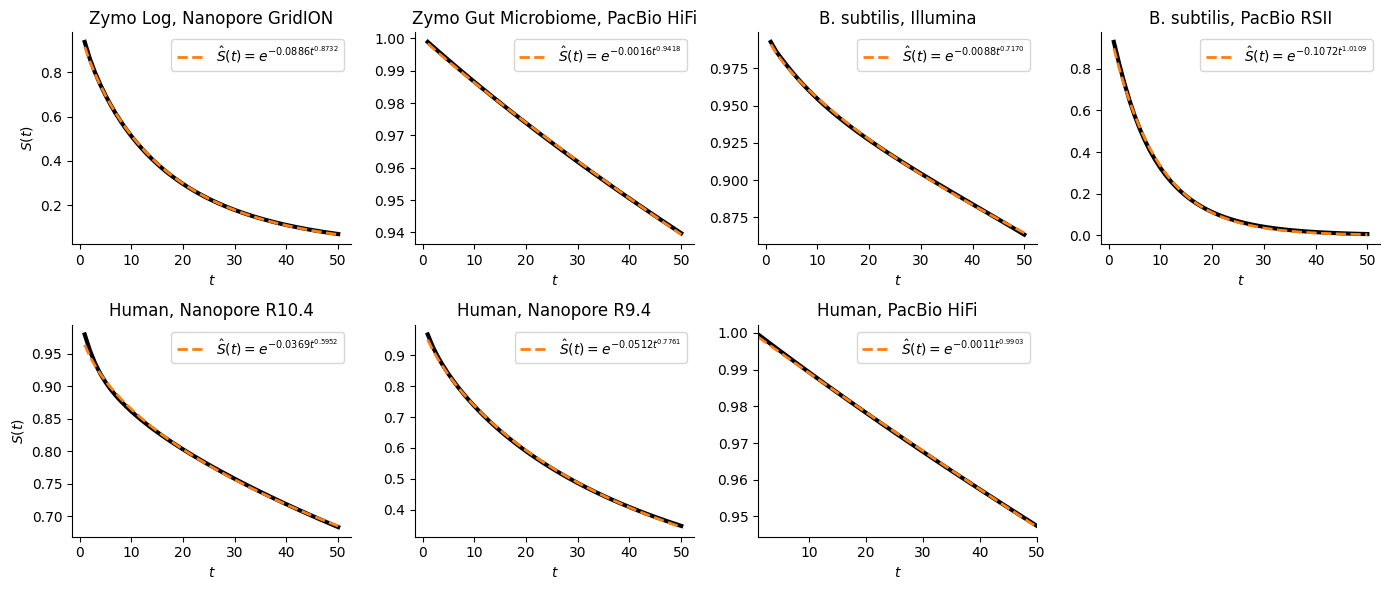

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns


# Define the function to fit
def fit_function_constant(i, alpha, beta):
    return np.exp(- alpha - beta * i)

def fit_function_normal(i, mean, std):
    return np.exp(- mean * i + (std ** 2) * (i ** 2) / 2)

def fit_function_discrete_weibull(i, l, k):
    return l ** (i ** k)


kmer_hit_rate_csv = [
    "../../output/zymo/ERR3152366.matched_kmers.csv",
    "../../output/zymo/SRR13128014.matched_kmers.csv",
    "../../output/zymo/ERR2935851_ref.matched_kmers.csv",
    "../../output/zymo/SRR7498042_ref.matched_kmers.csv",
    "../../output/human/HG002.matched_kmers.csv",
    "../../output/human/HG002_R941.matched_kmers.csv",
    "../../output/human/HG002_hifi.matched_kmers.csv"
]

labels = [
    "Zymo Log, Nanopore GridION",
    "Zymo Gut Microbiome, PacBio HiFi",
    "B. subtilis, Illumina",
    "B. subtilis, PacBio RSII",
    "Human, Nanopore R10.4",
    "Human, Nanopore R9.4",
    "Human, PacBio HiFi"
]

# Plot in 3 separate figures, the hazard ratio and the predicted k-mer hit rate.
# The hazard ratio is calculated by matched_kmers(k) / matched_kmers(k-1)
font_size = 8  # Set a common font size for labels and titles
hazard_ratio_plot_range = range(1, 51)
hazard_ratio_estimate_range = range(1, 51)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

func = fit_function_discrete_weibull
#func = fit_function_constant

ground_truth_survival_rate = []

for i in range(len(kmer_hit_rate_csv)):
    kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv[i])
    survival_rates = kmer_hit_rate_df['num_kmer_hit'].values

    
    survival_rates_esimates = survival_rates[hazard_ratio_estimate_range.start - 1:hazard_ratio_estimate_range.stop - 1]
    
    survival_rates_plot = survival_rates[hazard_ratio_plot_range.start - 1:hazard_ratio_plot_range.stop - 1]
    ground_truth_survival_rate.append(survival_rates_plot)
    
    # Fit the curve alpha/(alpha + beta + t) to the hazard ratios
    params, _ = curve_fit(func, list(hazard_ratio_estimate_range), survival_rates_esimates)
    alpha, bet = params
    print(f"Fitted parameters: alpha = {alpha:.6f}, beta = {bet:.6f}")
    l = -np.log(alpha)

    math_label = '$\hat{S}(t) = e^{%.4ft^{%.4f}}$' % (-l, bet)

    #axes[i].set_yscale('log')
    #axes[i].set_xscale('log')

    axes[i].plot(hazard_ratio_plot_range, survival_rates_plot, linewidth=3, color='black')
    fitted_hazard_ratios = [func(t, alpha, bet) for t in hazard_ratio_plot_range]
    axes[i].plot(hazard_ratio_plot_range, fitted_hazard_ratios, linewidth=2, linestyle='--', label=math_label, color='C1')
    
    axes[i].tick_params(axis='both')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

    axes[i].set_title(labels[i])
    axes[i].set_xlabel('$t$')
    if i % 4 == 0:
        axes[i].set_ylabel('$S(t)$')
    axes[i].legend()

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.xlim(hazard_ratio_plot_range.start, hazard_ratio_plot_range.stop - 1)
plt.savefig("../../figures/survival_rate_best_fit.pdf")
plt.show()
#plt.ylim(0, 0.05)

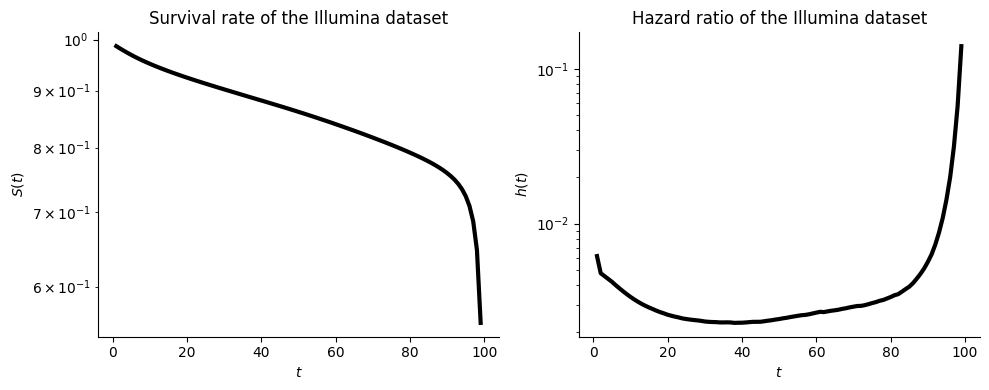

In [3]:
kmer_hit_rate_csv = "../../output/zymo/ERR2935851_ref.matched_kmers.csv"

hazard_ratio_plot_range = range(1, 100)
hazard_ratio_estimate_range = range(21, 31)




kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv)
survival_rates = kmer_hit_rate_df['num_kmer_hit'].values

hazard_ratios = []
for j in range(1, len(survival_rates)):
    hazard_ratio = 1 - (survival_rates[j] / survival_rates[j - 1])
    hazard_ratios.append(hazard_ratio)

hazard_ratio_esimates = hazard_ratios[hazard_ratio_estimate_range.start - 1:hazard_ratio_estimate_range.stop - 1]
hazard_ratio_plot = hazard_ratios[hazard_ratio_plot_range.start - 1:hazard_ratio_plot_range.stop - 1]

# Plot the survival rates and the hazard ratio in two subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(range(1, len(survival_rates)), survival_rates[1:], color='black', linewidth=3)
axes[0].set_title('Survival rate of the Illumina dataset')
axes[0].set_ylabel('$S(t)$')
axes[0].set_yscale('log')
axes[0].set_xlabel('$t$')

axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].plot(hazard_ratio_plot_range, hazard_ratio_plot, color='black', linewidth=3)
axes[1].set_ylabel('$h(t)$')
axes[1].set_title('Hazard ratio of the Illumina dataset')
axes[1].set_yscale('log')
axes[1].set_xlabel('$t$')

axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("../../figures/survival_rate_and_hazard_ratio_Illumina.pdf")

<>:70: SyntaxWarning: invalid escape sequence '\h'
<>:70: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_969914/2724294562.py:70: SyntaxWarning: invalid escape sequence '\h'
  math_label = '$\hat{S}(t) = e^{%.4ft}$' % (l)
/tmp/ipykernel_969914/2724294562.py:65: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(func, list(hazard_ratio_estimate_range), survival_rates_esimates)
/tmp/ipykernel_969914/2724294562.py:65: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(func, list(hazard_ratio_estimate_range), survival_rates_esimates)
/tmp/ipykernel_969914/2724294562.py:65: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(func, list(hazard_ratio_estimate_range), survival_rates_esimates)
/tmp/ipykernel_969914/2724294562.py:65: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(func, list(hazard_ratio_estimate_ran

Fitted parameters: alpha = 0.941708, beta = 1.000000
Fitted parameters: alpha = 0.998813, beta = 1.000000
Fitted parameters: alpha = 0.996946, beta = 1.000000
Fitted parameters: alpha = 0.895772, beta = 1.000000
Fitted parameters: alpha = 0.992928, beta = 1.000000
Fitted parameters: alpha = 0.979028, beta = 1.000000
Fitted parameters: alpha = 0.998945, beta = 1.000000


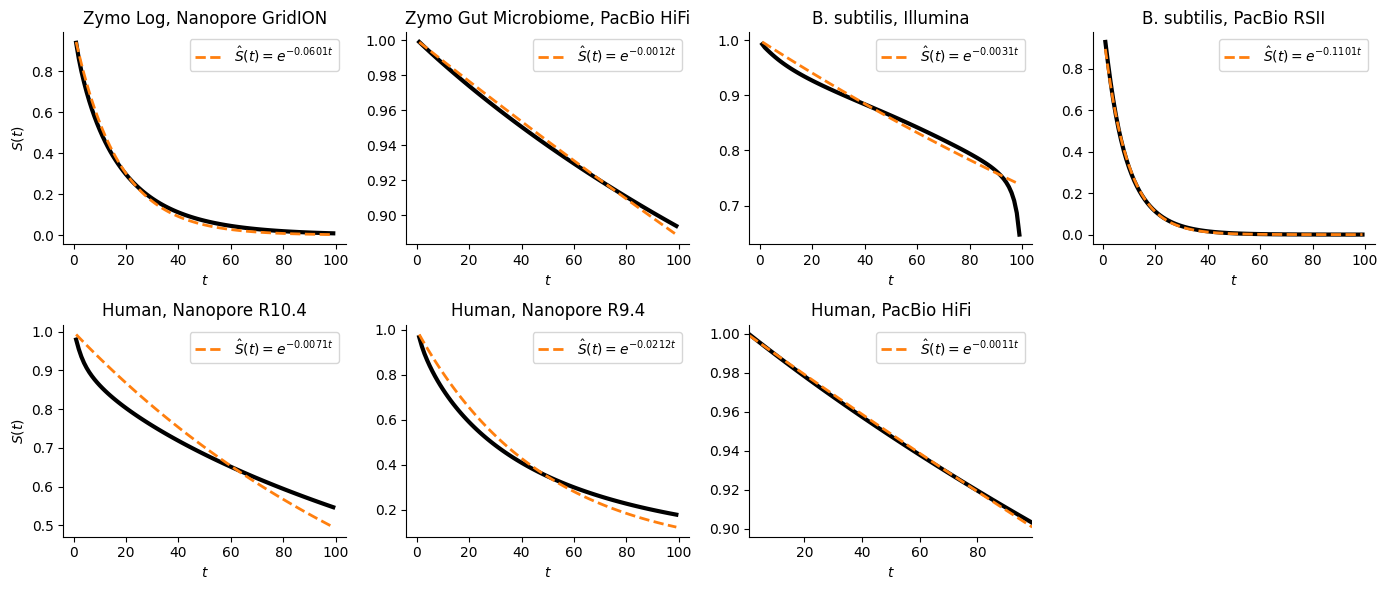

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns


# Define the function to fit
def fit_function_constant(i, alpha, beta):
    return np.exp(- alpha - beta * i)

def fit_function_normal(i, mean, std):
    return np.exp(- mean * i + (std ** 2) * (i ** 2) / 2)

def fit_function_discrete_weibull(i, l, k):
    return l ** (i ** 1)


kmer_hit_rate_csv = [
    "../../output/zymo/ERR3152366.matched_kmers.csv",
    "../../output/zymo/SRR13128014.matched_kmers.csv",
    "../../output/zymo/ERR2935851_ref.matched_kmers.csv",
    "../../output/zymo/SRR7498042_ref.matched_kmers.csv",
    "../../output/human/HG002.matched_kmers.csv",
    "../../output/human/HG002_R941.matched_kmers.csv",
    "../../output/human/HG002_hifi.matched_kmers.csv"
]

labels = [
    "Zymo Log, Nanopore GridION",
    "Zymo Gut Microbiome, PacBio HiFi",
    "B. subtilis, Illumina",
    "B. subtilis, PacBio RSII",
    "Human, Nanopore R10.4",
    "Human, Nanopore R9.4",
    "Human, PacBio HiFi"
]

# Plot in 3 separate figures, the hazard ratio and the predicted k-mer hit rate.
# The hazard ratio is calculated by matched_kmers(k) / matched_kmers(k-1)
font_size = 8  # Set a common font size for labels and titles
hazard_ratio_plot_range = range(1, 100)
hazard_ratio_estimate_range = range(1, 100)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

func = fit_function_discrete_weibull
#func = fit_function_constant

for i in range(len(kmer_hit_rate_csv)):
    kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv[i])
    survival_rates = kmer_hit_rate_df['num_kmer_hit'].values

    hazard_rates = []
    for j in range(1, len(survival_rates)):
        hazard_rate = 1 - survival_rates[j] / survival_rates[j - 1]
        hazard_rates.append(hazard_rate)

    
    survival_rates_esimates = survival_rates[hazard_ratio_estimate_range.start - 1:hazard_ratio_estimate_range.stop - 1]
    survival_rates_plot = survival_rates[hazard_ratio_plot_range.start - 1:hazard_ratio_plot_range.stop - 1]
    
    # Fit the curve alpha/(alpha + beta + t) to the hazard ratios
    params, _ = curve_fit(func, list(hazard_ratio_estimate_range), survival_rates_esimates)
    alpha, bet = params
    print(f"Fitted parameters: alpha = {alpha:.6f}, beta = {bet:.6f}")
    l = np.log(alpha)

    math_label = '$\hat{S}(t) = e^{%.4ft}$' % (l)

    #axes[i].set_yscale('log')
    #axes[i].set_xscale('log')

    axes[i].plot(hazard_ratio_plot_range, survival_rates_plot, linewidth=3, color='black')
    fitted_hazard_ratios = [func(t, alpha, bet) for t in hazard_ratio_plot_range]
    axes[i].plot(hazard_ratio_plot_range, fitted_hazard_ratios, linewidth=2, linestyle='--', label=math_label, color='C1')
    
    axes[i].tick_params(axis='both')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

    axes[i].set_title(labels[i])
    axes[i].set_xlabel('$t$')
    if i % 4 == 0:
        axes[i].set_ylabel('$S(t)$')
    axes[i].legend()

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.xlim(hazard_ratio_plot_range.start, hazard_ratio_plot_range.stop - 1)
#plt.savefig("../../figures/figureS1_B.svg")
plt.show()
#plt.ylim(0, 0.05)

# Plot hazard rate predictions

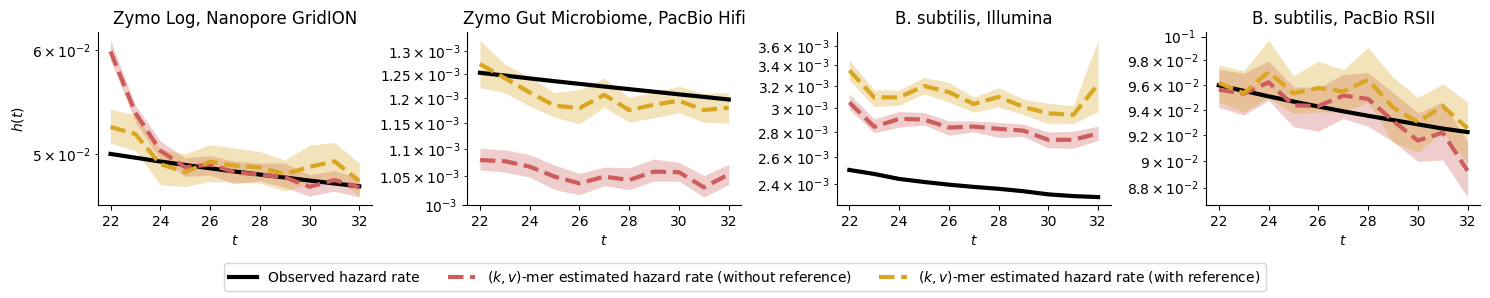

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns

# Set seaborn style

# Define the function to fit

kmer_hit_rate_csv = [
    "../../output/zymo/ERR3152366.matched_kmers.csv",
    "../../output/zymo/SRR13128014.matched_kmers.csv",
    "../../output/zymo/ERR2935851_ref.matched_kmers.csv",
    "../../output/zymo/SRR7498042_ref.matched_kmers.csv"
]


t_range = [
    range(22, 33),
    range(22, 33),
    range(22, 33),
    range(22, 33)
]

labels = [
    "Zymo Log, Nanopore GridION",
    "Zymo Gut Microbiome, PacBio Hifi",
    "B. subtilis, Illumina",
    "B. subtilis, PacBio RSII"
]

kvmer_hazard_rate_csv = [
    "../../output/zymo/ERR3152366_bi_kvmer_hazard_ratio.csv",
    "../../output/zymo/SRR13128014_bi_kvmer_hazard_ratio.csv",
    "../../output/zymo/ERR2935851_bi_kvmer_hazard_ratio.csv",
    "../../output/zymo/SRR7498042_bi_kvmer_hazard_ratio.csv"
]

kvmer_report_csv = [
    "../../output/zymo/ERR3152366_bi_kvmer.csv",
    "../../output/zymo/SRR13128014_bi_kvmer.csv",
    "../../output/zymo/ERR2935851_bi_kvmer.csv",
    "../../output/zymo/SRR7498042_bi_kvmer.csv"
]

kvmer_ref_hazard_rate_csv = [
    "../../output/zymo/ERR3152366_bi_kvmer_ref_hazard_ratio.csv",
    "../../output/zymo/SRR13128014_bi_kvmer_ref_hazard_ratio.csv",
    "../../output/zymo/ERR2935851_bi_kvmer_ref_hazard_ratio.csv",
    "../../output/zymo/SRR7498042_bi_kvmer_ref_hazard_ratio.csv"
]

kvmer_ref_report_csv = [
    "../../output/zymo/ERR3152366_bi_kvmer_ref.csv",
    "../../output/zymo/SRR13128014_bi_kvmer_ref.csv",
    "../../output/zymo/ERR2935851_bi_kvmer_ref.csv",
    "../../output/zymo/SRR7498042_bi_kvmer_ref.csv"
]



mapping_results = [
    # Reported mapping identity by minimap2
    0.883148,
    0.992763,
    0.868784,
    0.963613
]

q_score_results = [
    # Reported ErrQ by seqtk
    16.7,
    27.7,
    9.0,
    30.1
]

kmer_results = [
    # Reported error rate by GenomeScope
    3.72975,
    0.613276,
    11.7262,
    1.076,
]



hazard_rate_estimates = []

for i in range(len(kvmer_hazard_rate_csv)):
    kvmer_report_df = pd.read_csv(kvmer_hazard_rate_csv[i])
    hazard_rate = kvmer_report_df['hazard_ratio'].values
    percentile_5th = kvmer_report_df['5th_percentile'].values
    percentile_95th = kvmer_report_df['95th_percentile'].values
    hazard_rate_res = {"hazard_rate": hazard_rate,
                             "percentile_5th": percentile_5th,
                             "percentile_95th": percentile_95th}
    hazard_rate_estimates.append(hazard_rate_res)

hazard_rate_estimates_ref = []
for i in range(len(kvmer_ref_hazard_rate_csv)):
    kvmer_report_df = pd.read_csv(kvmer_ref_hazard_rate_csv[i])
    hazard_rate = kvmer_report_df['hazard_ratio'].values
    percentile_5th = kvmer_report_df['5th_percentile'].values
    percentile_95th = kvmer_report_df['95th_percentile'].values
    hazard_rate_res = {"hazard_rate": hazard_rate,
                             "percentile_5th": percentile_5th,
                             "percentile_95th": percentile_95th}
    hazard_rate_estimates_ref.append(hazard_rate_res)
    

def q_score_to_error_rate(q):
    return 10 ** (-q / 10)

def kmer_error_to_error_rate(e):
    return (e / 100)


# Plot in 3 separate figures, the hazard ratio and the predicted k-mer hit rate.
# The hazard ratio is calculated by matched_kmers(k) / matched_kmers(k-1)
font_size = 8  # Set a common font size for labels and titles
fig, axes = plt.subplots(1, 4, figsize=(15, 3))
axes = axes.flatten()

for i in range(len(kmer_hit_rate_csv)):
    kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv[i])
    plot_range = t_range[i]
    survival_rates = kmer_hit_rate_df['num_kmer_hit'].values
    survival_rates_plot = survival_rates[plot_range.start - 1:plot_range.stop - 1]
    hazard_ratios = []
    for j in range(1, len(survival_rates)):
        hazard_ratio = 1 - (survival_rates[j] / survival_rates[j - 1])
        hazard_ratios.append(hazard_ratio)
    
    hazard_ratio_plot = hazard_ratios[plot_range.start - 1:plot_range.stop - 1]


    kvmer_fit_df = pd.read_csv(kvmer_report_csv[i])
    lambd = kvmer_fit_df['lambda'].item()
    beta = kvmer_fit_df['beta'].item()
    fitted_hazard_rates = [1 - np.exp(-lambd * ((t+1) ** beta - t ** beta)) for t in plot_range]

    # Calculate the survival rate for mapping
    estimated_hr = hazard_rate_estimates[i]['hazard_rate']
    estimated_hr_upper = hazard_rate_estimates[i]['percentile_95th']
    estimated_hr_lower = hazard_rate_estimates[i]['percentile_5th']
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)


    axes[i].plot(plot_range, hazard_ratio_plot, linewidth=3,  label='Ground truth hazard rate', color='black')
    axes[i].plot(plot_range, estimated_hr, linewidth=3,  linestyle='--', label='skiver estimated hazard rate (without reference)', color='indianred')
    #axes[i].plot(plot_range, fitted_hazard_rates, linewidth=2, linestyle=':', label='$(k,v)$-mer fitted hazard rate curve', color='C3')
    
    axes[i].fill_between(plot_range, estimated_hr_lower, estimated_hr_upper,  linewidth=0, color='indianred', alpha=0.3)

    axes[i].plot(plot_range, hazard_rate_estimates_ref[i]['hazard_rate'], linewidth=3,   linestyle='--', label='skiver estimated hazard rate (with reference)', color='goldenrod')
    axes[i].fill_between(plot_range, hazard_rate_estimates_ref[i]['percentile_5th'],  hazard_rate_estimates_ref[i]['percentile_95th'], linewidth=0, color='goldenrod', alpha=0.3)
    #axes[i].plot(plot_range, [1 - mapping_results[i]] * len(plot_range), linewidth=2, linestyle='--', color='C4', label='Reported Mapping Identity')

    #axes[i].plot(plot_range, [q_score_to_error_rate(q_score_results[i])] * len(plot_range), linewidth=2, linestyle='--', color='C2', label='Predicted from Q Score')
    #axes[i].plot(plot_range, [kmer_error_to_error_rate(kmer_results[i])] * len(plot_range), linewidth=2, linestyle='--', color='C3', label='Predicted from K-mer Error Rate')


    axes[i].set_yscale('log')
    #axes[i].set_xscale('log')
    
    
    
    axes[i].tick_params(axis='both')

    axes[i].set_title(labels[i])
    #axes[i].set_ylim(bottom=0)
    
    axes[i].set_xlabel('$t$')
    if i  == 0:
        axes[i].set_ylabel('$h(t)$')
    #axes[i].legend()
    #axes[i].legend()

plt.tight_layout()
handles, labels = axes[0].get_legend_handles_labels()

# Add the legend to the bottom of the figure
fig.legend(handles, labels, loc='lower center', ncol=5)
fig.subplots_adjust(wspace=0.35, bottom=0.3)


plt.savefig("../../figures/metagenomic_hazard_rate_comparison.svg")
#plt.ylim(0, 0.05)

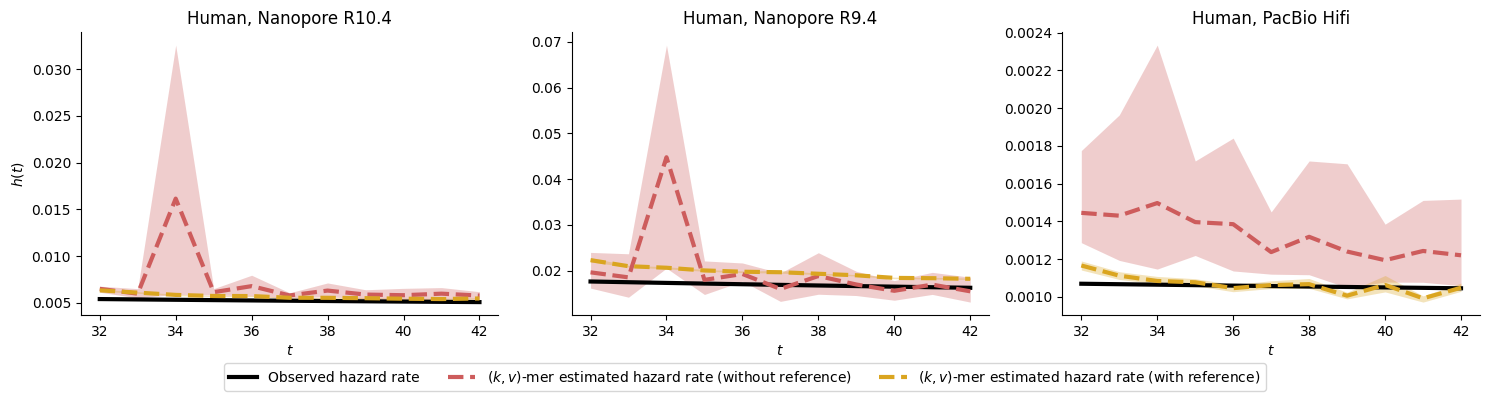

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns

# Set seaborn style

# Define the function to fit

kmer_hit_rate_csv = [
    "../../output/human/HG002.matched_kmers.csv",
    "../../output/human/HG002_R941.matched_kmers.csv",
    "../../output/human/HG002_hifi.matched_kmers.csv",
]


t_range = [
    range(32, 43),
    range(32, 43),
    range(32, 43),
]

labels = [
    "Human, Nanopore R10.4",
    "Human, Nanopore R9.4",
    "Human, PacBio Hifi",
]

kvmer_hazard_rate_csv = [
    "../../output/human/HG002_bi_kvmer_hazard_ratio.csv",
    "../../output/human/HG002_R941_bi_kvmer_hazard_ratio.csv",
    "../../output/human/HG002_hifi_bi_kvmer_hazard_ratio.csv",
]

kvmer_ref_hazard_rate_csv = [
    "../../output/human/HG002_bi_kvmer_ref_hazard_ratio.csv",
    "../../output/human/HG002_R941_bi_kvmer_ref_hazard_ratio.csv",
    "../../output/human/HG002_hifi_bi_kvmer_ref_hazard_ratio.csv",
]



mapping_results = [
    # Reported mapping identity by minimap2
    0.883148,
    0.992763,
    0.868784,
    0.963613
]

q_score_results = [
    # Reported ErrQ by seqtk
    16.7,
    27.7,
    9.0,
    30.1
]

kmer_results = [
    # Reported error rate by GenomeScope
    3.72975,
    0.613276,
    11.7262,
    1.076,
]



hazard_rate_estimates = []

for i in range(len(kvmer_hazard_rate_csv)):
    kvmer_report_df = pd.read_csv(kvmer_hazard_rate_csv[i])
    hazard_rate = kvmer_report_df['hazard_ratio'].values
    percentile_5th = kvmer_report_df['5th_percentile'].values
    percentile_95th = kvmer_report_df['95th_percentile'].values
    hazard_rate_res = {"hazard_rate": hazard_rate,
                             "percentile_5th": percentile_5th,
                             "percentile_95th": percentile_95th}
    hazard_rate_estimates.append(hazard_rate_res)

hazard_rate_estimates_ref = []
for i in range(len(kvmer_ref_hazard_rate_csv)):
    kvmer_report_df = pd.read_csv(kvmer_ref_hazard_rate_csv[i])
    hazard_rate = kvmer_report_df['hazard_ratio'].values
    percentile_5th = kvmer_report_df['5th_percentile'].values
    percentile_95th = kvmer_report_df['95th_percentile'].values
    hazard_rate_res = {"hazard_rate": hazard_rate,
                             "percentile_5th": percentile_5th,
                             "percentile_95th": percentile_95th}
    hazard_rate_estimates_ref.append(hazard_rate_res)
    

def q_score_to_error_rate(q):
    return 10 ** (-q / 10)

def kmer_error_to_error_rate(e):
    return (e / 100)


# Plot in 3 separate figures, the hazard ratio and the predicted k-mer hit rate.
# The hazard ratio is calculated by matched_kmers(k) / matched_kmers(k-1)
font_size = 8  # Set a common font size for labels and titles
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes = axes.flatten()

for i in range(len(kmer_hit_rate_csv)):
    kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv[i])
    plot_range = t_range[i]
    survival_rates = kmer_hit_rate_df['num_kmer_hit'].values
    survival_rates_plot = survival_rates[plot_range.start - 1:plot_range.stop - 1]
    hazard_ratios = []
    for j in range(1, len(survival_rates)):
        hazard_ratio = 1 - (survival_rates[j] / survival_rates[j - 1])
        hazard_ratios.append(hazard_ratio)
    
    hazard_ratio_plot = hazard_ratios[plot_range.start - 1:plot_range.stop - 1]

    # Calculate the survival rate for mapping
    estimated_hr = hazard_rate_estimates[i]['hazard_rate']
    estimated_hr_upper = hazard_rate_estimates[i]['percentile_95th']
    estimated_hr_lower = hazard_rate_estimates[i]['percentile_5th']
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)


    axes[i].plot(plot_range, hazard_ratio_plot, linewidth=3,  label='Ground truth hazard rate', color='black')
    axes[i].plot(plot_range, estimated_hr, linewidth=3,  linestyle='--', label='skiver estimated hazard rate (without reference)', color='indianred')
    axes[i].fill_between(plot_range, estimated_hr_lower, estimated_hr_upper,  linewidth=0, color='indianred', alpha=0.3)

    axes[i].plot(plot_range, hazard_rate_estimates_ref[i]['hazard_rate'], linewidth=3,   linestyle='--', label='skiver estimated hazard rate (with reference)', color='goldenrod')
    axes[i].fill_between(plot_range, hazard_rate_estimates_ref[i]['percentile_5th'],  hazard_rate_estimates_ref[i]['percentile_95th'], linewidth=0, color='goldenrod', alpha=0.3)
    #axes[i].plot(plot_range, [1 - mapping_results[i]] * len(plot_range), linewidth=2, linestyle='--', color='C4', label='Reported Mapping Identity')

    #axes[i].plot(plot_range, [q_score_to_error_rate(q_score_results[i])] * len(plot_range), linewidth=2, linestyle='--', color='C2', label='Predicted from Q Score')
    #axes[i].plot(plot_range, [kmer_error_to_error_rate(kmer_results[i])] * len(plot_range), linewidth=2, linestyle='--', color='C3', label='Predicted from K-mer Error Rate')


    #axes[i].set_yscale('log')
    #axes[i].set_xscale('log')
    
    
    
    axes[i].tick_params(axis='both')
    #if i == 0:
    #    axes[i].set_ylim(0.004, 0.01)

    axes[i].set_title(labels[i])
    #axes[i].set_ylim(bottom=0)
    
    axes[i].set_xlabel('$t$')
    if i  == 0:
        axes[i].set_ylabel('$h(t)$')
    #axes[i].legend()
    #axes[i].legend()

plt.tight_layout()
handles, labels = axes[0].get_legend_handles_labels()

# Add the legend to the bottom of the figure
fig.legend(handles, labels, loc='lower center', ncol=5)
fig.subplots_adjust(bottom=0.2)


plt.savefig("../../figures/human_hazard_rate_comparison.pdf")
#plt.ylim(0, 0.05)

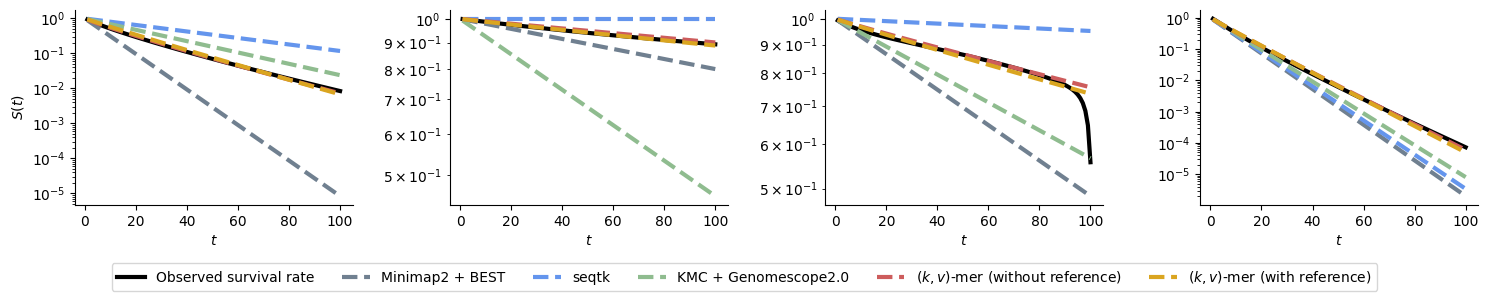

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns

# Set seaborn style

# Define the function to fit
def fit_function_beta(i, alpha, beta):
    return alpha / (alpha + beta + i)

def fit_function_normal(i, mean, std):
    return np.exp(- mean + (i + 0.5) * (std * std))

def fit_function_weibull(i, a, b):
    return a * (i ** b)

def fit_function_gamma(i, alpha, beta):
    return (alpha * beta) / (1 + beta * i)

kmer_hit_rate_csv = [
    "../../output/zymo/ERR3152366.matched_kmers.csv",
    "../../output/zymo/SRR13128014.matched_kmers.csv",
    "../../output/zymo/ERR2935851_ref.matched_kmers.csv",
    "../../output/zymo/SRR7498042_ref.matched_kmers.csv",
    
]

labels = [
    "Zymo Log, Nanopore GridION",
    "Zymo Gut Microbiome, PacBio HiFi",
    "B. subtilis, Illumina",
    "B. subtilis, PacBio RSII",
    
]

kvmer_report_csv = [
    "../../output/zymo/ERR3152366_bi_kvmer.csv",
    "../../output/zymo/SRR13128014_bi_kvmer.csv",
    "../../output/zymo/ERR2935851_bi_kvmer.csv",
    "../../output/zymo/SRR7498042_bi_kvmer.csv",
    
    #"../../output/human/HG002_hifi_bi_kvmer.csv"
    
]

kvmer_ref_report_csv = [
    "../../output/zymo/ERR3152366_bi_kvmer_ref.csv",
    "../../output/zymo/SRR13128014_bi_kvmer_ref.csv",
    "../../output/zymo/ERR2935851_bi_kvmer_ref.csv",
    "../../output/zymo/SRR7498042_bi_kvmer_ref.csv",
    
    #"../../output/human/HG002_hifi_bi_kvmer_ref.csv"
]

mapping_results = [
    # Reported mapping identity by minimap2
    0.883148,
    0.997772,
    0.992763,
    0.868784,
    
]

q_score_results = [
    # Reported ErrQ by seqtk
    16.7,
    82.9,
    33.0,
    9.0,
    
]

kmer_results = [
    # Reported error rate by GenomeScope
    3.72975,
    0.785707,
    0.569278,
    11.7262,
    
]



weibull_fit_results = []

for i in range(len(kvmer_report_csv)):
    kvmer_report_df = pd.read_csv(kvmer_report_csv[i])
    a = kvmer_report_df['lambda'].item()
    b = kvmer_report_df['beta'].item()
    weibull_fit_results.append((a, b))

weibull_fit_results_ref = []
for i in range(len(kvmer_ref_report_csv)):
    kvmer_report_df = pd.read_csv(kvmer_ref_report_csv[i])
    a = kvmer_report_df['lambda'].item()
    b = kvmer_report_df['beta'].item()
    weibull_fit_results_ref.append((a, b))

def q_score_to_identity(q):
    return 1 - 10 ** (-q / 10)

def kmer_error_to_identity(e):
    return (1 - e / 100)

def estimate_survival_rate_from_identity(identity, k):
    return np.exp(-(1-identity) * k)

def estimate_survival_rate_list_from_beta(alpha, beta, max_k):
    survival_rates = []
    for k in range(1, max_k + 1):
        hazard_rate = fit_function_beta(k, alpha, beta)
        if k == 1:
            survival_rate = 1 - hazard_rate
        else:
            survival_rate = survival_rates[-1] * (1 - hazard_rate)
        survival_rates.append(survival_rate)
    return survival_rates

def estimate_survival_rate_from_weibull(l, b, k):
    return np.exp(- l * (k ** b))

# Plot in 3 separate figures, the hazard ratio and the predicted k-mer hit rate.
# The hazard ratio is calculated by matched_kmers(k) / matched_kmers(k-1)
font_size = 8  # Set a common font size for labels and titles
plot_range = range(1, 101)
fig, axes = plt.subplots(1, 4, figsize=(15, 3))
axes = axes.flatten()



survival_rate_mise = {
    "BEST + Minimap2": [],
    "seqtk": [],
    "KMC + GenomeScope2.0": [],
    "Kvmer": [],
    "Kvmer (with ref)": []
}

hazard_rate_mise = {
    "BEST + Minimap2": [],
    "seqtk": [],
    "KMC + GenomeScope2.0": [],
    "Kvmer": [],
    "Kvmer (with ref)": []
}

for i in range(len(kmer_hit_rate_csv)):
    kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv[i])
    survival_rates = kmer_hit_rate_df['num_kmer_hit'].values
    survival_rates_plot = survival_rates[plot_range.start - 1:plot_range.stop - 1]

    # Calculate the survival rate for mapping
    survival_rates_mapping = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(mapping_results[i], k)
        survival_rates_mapping.append(survival_rate)
    mapping_error_rate = 1 - mapping_results[i]
    survival_rate_mise['BEST + Minimap2'].append(
        find_survival_rate_mise_error_rate(survival_rates_plot, mapping_error_rate)
        )
    #print(survival_rates_plot, mapping_error_rate)
    hazard_rate_mise['BEST + Minimap2'].append(
        
        find_hazard_rate_mise_error_rate(survival_rates_plot, mapping_error_rate)
        )
    
    survival_rates_qscore = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(q_score_to_identity(q_score_results[i]), k)
        survival_rates_qscore.append(survival_rate)
    q_score_error_rate = 1 - q_score_to_identity(q_score_results[i])
    survival_rate_mise['seqtk'].append(
        find_survival_rate_mise_error_rate(survival_rates_plot, q_score_error_rate)
        )
    hazard_rate_mise['seqtk'].append(
        find_hazard_rate_mise_error_rate(survival_rates_plot, q_score_error_rate)
        )
    
    survival_rates_kmer = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(kmer_error_to_identity(kmer_results[i]), k)
        survival_rates_kmer.append(survival_rate)
    kmer_error_rate = 1 - kmer_error_to_identity(kmer_results[i])
    survival_rate_mise['KMC + GenomeScope2.0'].append(
        find_survival_rate_mise_error_rate(survival_rates_plot, kmer_error_rate)
        )
    hazard_rate_mise['KMC + GenomeScope2.0'].append(
        find_hazard_rate_mise_error_rate(survival_rates_plot, kmer_error_rate)
        )
    
    #survival_rates_beta = estimate_survival_rate_list_from_beta(beta_fit_results[i][0], beta_fit_results[i][1], plot_range.stop - 1)
    #survival_rates_beta = survival_rates_beta[plot_range.start - 1:plot_range.stop - 1]

    #survival_rates_const_hazard = []
    #for k in plot_range:
    #    survival_rate = (1 - (beta_fit_results[i][0] / (beta_fit_results[i][0] + beta_fit_results[i][1]))) ** k
    #    survival_rates_const_hazard.append(survival_rate)

    survival_rates_weibull = []
    survival_rates_weibull_ref = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_weibull(weibull_fit_results[i][0], weibull_fit_results[i][1], k)
        surival_rate_ref = estimate_survival_rate_from_weibull(weibull_fit_results_ref[i][0], weibull_fit_results_ref[i][1], k)
        survival_rates_weibull.append(survival_rate)
        survival_rates_weibull_ref.append(surival_rate_ref)
    
    survival_rate_mise['Kvmer'].append(
        find_survival_rate_mise_weibull(survival_rates_plot, weibull_fit_results[i][0], weibull_fit_results[i][1])
        )
    hazard_rate_mise['Kvmer'].append(
        find_hazard_rate_mise_weibull(survival_rates_plot, weibull_fit_results[i][0], weibull_fit_results[i][1])
        )
    survival_rate_mise['Kvmer (with ref)'].append(
        find_survival_rate_mise_weibull(survival_rates_plot, weibull_fit_results_ref[i][0], weibull_fit_results_ref[i][1])
        )
    hazard_rate_mise['Kvmer (with ref)'].append(
        find_hazard_rate_mise_weibull(survival_rates_plot, weibull_fit_results_ref[i][0], weibull_fit_results_ref[i][1])
        )
    

    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)



    axes[i].plot(plot_range, survival_rates_plot, linewidth=3, label='Ground truth survival rate', color='black')
    axes[i].plot(plot_range, survival_rates_mapping, linewidth=3, linestyle='--', label='Minimap2 + BEST', color='slategray')
    axes[i].plot(plot_range, survival_rates_qscore, linewidth=3, linestyle='--', label='seqtk', color='cornflowerblue')
    axes[i].plot(plot_range, survival_rates_kmer, linewidth=3, linestyle='--', label='KMC + Genomescope2.0', color='darkseagreen')
    #axes[i].plot(plot_range, survival_rates_beta, linewidth=2, linestyle='-', label='Predicted from Beta Fit', color='C4')
    #axes[i].plot(plot_range, survival_rates_const_hazard, linewidth=2, linestyle='--', label='Predicted from Constant Hazard', color='C5')
    axes[i].plot(plot_range, survival_rates_weibull, linewidth=3, linestyle='--', label='skiver (without reference)', color='indianred')
    axes[i].plot(plot_range, survival_rates_weibull_ref, linewidth=3, linestyle='--', label='skiver (with reference)', color='goldenrod')

    axes[i].set_yscale('log')
    #axes[i].set_xscale('log')
    
    
    
    axes[i].tick_params(axis='both')

    #axes[i].set_title(labels[i])
    
    axes[i].set_xlabel('$t$')
    if i  == 0:
        axes[i].set_ylabel('$S(t)$')
    #axes[i].legend()
    #axes[i].legend()

handles, labels = axes[0].get_legend_handles_labels()
plt.tight_layout()

# Add the legend to the bottom of the figure
fig.legend(handles, labels, loc='lower center', ncol=6)
fig.subplots_adjust(wspace=0.35, bottom=0.3)
#plt.tight_layout()


plt.savefig("../../figures/metagenomic_survival_rate.svg")
#plt.ylim(0, 0.05)




In [9]:
survival_rate_mise_all = pd.DataFrame(survival_rate_mise)
pd.DataFrame(survival_rate_mise)

,BEST + Minimap2,seqtk,KMC + GenomeScope2.0,Kvmer,Kvmer (with ref)
0,0.014049,0.063834,0.010454,0.000029,0.000779
1,0.002864,0.004360,0.079516,0.000045,0.000003
2,0.027951,0.018342,0.012443,0.000676,0.000549
3,0.001230,0.000853,0.000361,0.000087,0.000113


In [10]:
hazard_rate_mise_all = pd.DataFrame(hazard_rate_mise)
pd.DataFrame(hazard_rate_mise)

,BEST + Minimap2,seqtk,KMC + GenomeScope2.0,Kvmer,Kvmer (with ref)
0,0.004994,0.000693,0.000144,1.905007e-05,3.604722e-05
1,0.000001,0.000001,0.000045,1.852186e-08,1.296769e-08
2,0.000226,0.000251,0.000224,2.327544e-04,2.312864e-04
3,0.001699,0.001297,0.000767,3.752981e-05,6.141679e-05


In [12]:

minimap_results = [1 - identity for identity in mapping_results]
qscore_results = [1 - q_score_to_identity(q) for q in q_score_results]
kmer_results = [1 - kmer_error_to_identity(e) for e in kmer_results]
weibull_results = [1 - np.exp(-weibull_fit_results[i][0]) for i in range(len(weibull_fit_results))]
weibull_ref_results = [1 - np.exp(-weibull_fit_results_ref[i][0]) for i in range(len(weibull_fit_results_ref))]

result_df = {"BEST + Minimap2": minimap_results, "seqtk": qscore_results, "KMC + Genomescope2.0": kmer_results,
             "(k,v)-mer (without reference)": weibull_results, "(k,v)-mer (with reference)": weibull_ref_results}
result_df = pd.DataFrame(result_df)
result_df 

,BEST + Minimap2,seqtk,KMC + Genomescope2.0,"(k,v)-mer (without reference)","(k,v)-mer (with reference)"
0,0.116852,2.137962e-02,0.037297,0.082163,0.058914
1,0.002228,5.128614e-09,0.007857,0.001161,0.001411
2,0.007237,5.011872e-04,0.005693,0.003632,0.003704
3,0.131216,1.258925e-01,0.117262,0.113110,0.104175


[(0.00806, 0.94164), (0.029311, 0.893542), (0.002217, 0.888729)]


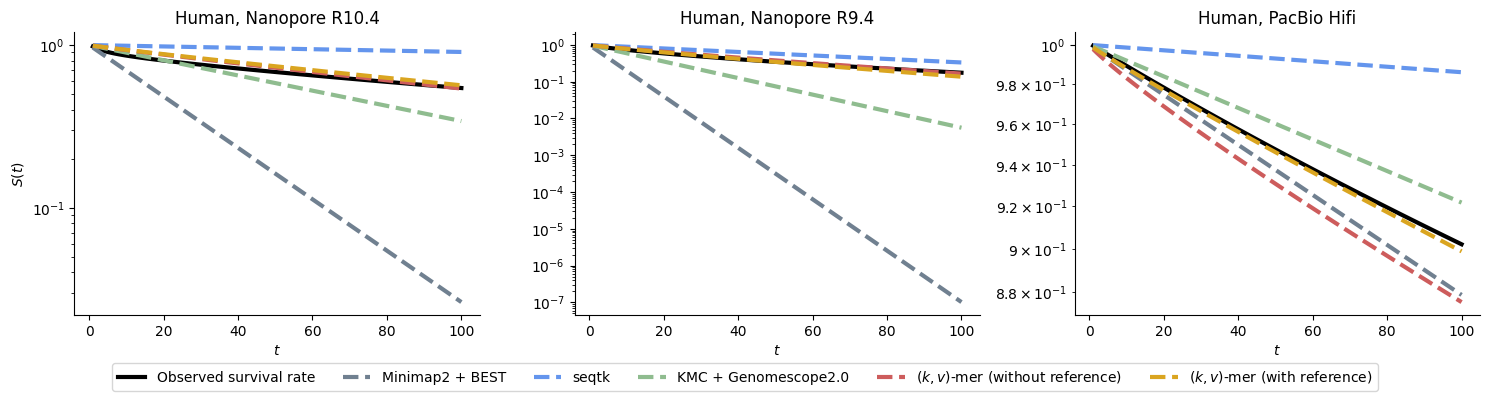

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns

# Set seaborn style

# Define the function to fit
def fit_function_beta(i, alpha, beta):
    return alpha / (alpha + beta + i)

def fit_function_normal(i, mean, std):
    return np.exp(- mean + (i + 0.5) * (std * std))

def fit_function_weibull(i, a, b):
    return a * (i ** b)

def fit_function_gamma(i, alpha, beta):
    return (alpha * beta) / (1 + beta * i)

kmer_hit_rate_csv = [
    "../../output/human/HG002.matched_kmers.csv",
    "../../output/human/HG002_R941.matched_kmers.csv",
    "../../output/human/HG002_hifi.matched_kmers.csv",
]


labels = [
    "Human, Nanopore R10.4",
    "Human, Nanopore R9.4",
    "Human, PacBio Hifi",
]

kvmer_report_csv = [
    "../../output/human/HG002_bi_kvmer.csv",
    "../../output/human/HG002_R941_bi_kvmer.csv",
    "../../output/human/HG002_hifi_bi_kvmer.csv",
]

kvmer_ref_report_csv = [
    "../../output/human/HG002_bi_kvmer_ref.csv",
    "../../output/human/HG002_R941_bi_kvmer_ref.csv",
    "../../output/human/HG002_hifi_bi_kvmer_ref.csv",
]




mapping_results = [
    # Reported mapping identity by minimap2
    0.963613, # R10.4
    0.838991, # r9.4.1
    0.998709 # hifi
]

q_score_results = [
    # Reported ErrQ by seqtk
    30.1, # R10.4
    19.6, # R9.4.1
    38.5 # hifi
]

kmer_results = [
    # Reported error rate by GenomeScope
    1.076, # R10.4
    5.18148, # R9.4.1
    0.0814363, #hifi
]



weibull_fit_results = []

for i in range(len(kvmer_report_csv)):
    kvmer_report_df = pd.read_csv(kvmer_report_csv[i])
    a = kvmer_report_df['lambda'].item()
    b = kvmer_report_df['beta'].item()
    weibull_fit_results.append((a, b))

weibull_fit_results_ref = []
for i in range(len(kvmer_ref_report_csv)):
    kvmer_report_df = pd.read_csv(kvmer_ref_report_csv[i])
    a = kvmer_report_df['lambda'].item()
    b = kvmer_report_df['beta'].item()
    weibull_fit_results_ref.append((a, b))

print(weibull_fit_results)

def q_score_to_identity(q):
    return 1 - 10 ** (-q / 10)

def kmer_error_to_identity(e):
    return (1 - e / 100)

def estimate_survival_rate_from_identity(identity, k):
    return np.exp(-(1-identity) * k)

def estimate_survival_rate_list_from_beta(alpha, beta, max_k):
    survival_rates = []
    for k in range(1, max_k + 1):
        hazard_rate = fit_function_beta(k, alpha, beta)
        if k == 1:
            survival_rate = 1 - hazard_rate
        else:
            survival_rate = survival_rates[-1] * (1 - hazard_rate)
        survival_rates.append(survival_rate)
    return survival_rates

def estimate_survival_rate_from_weibull(a, b, k):
    return np.exp(- a * (k ** b))

# Plot in 3 separate figures, the hazard ratio and the predicted k-mer hit rate.
# The hazard ratio is calculated by matched_kmers(k) / matched_kmers(k-1)
font_size = 8  # Set a common font size for labels and titles
plot_range = range(1, 101)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes = axes.flatten()

for i in range(len(kmer_hit_rate_csv)):
    kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv[i])
    survival_rates = kmer_hit_rate_df['num_kmer_hit'].values
    survival_rates_plot = survival_rates[plot_range.start - 1:plot_range.stop - 1]

    # Calculate the survival rate for mapping
    survival_rates_mapping = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(mapping_results[i], k)
        survival_rates_mapping.append(survival_rate)
    mapping_error_rate = 1 - mapping_results[i]
    survival_rate_mise['BEST + Minimap2'].append(
        find_survival_rate_mise_error_rate(survival_rates_plot, mapping_error_rate)
        )
    #print(survival_rates_plot, mapping_error_rate)
    hazard_rate_mise['BEST + Minimap2'].append(
        
        find_hazard_rate_mise_error_rate(survival_rates_plot, mapping_error_rate)
        )
    
    survival_rates_qscore = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(q_score_to_identity(q_score_results[i]), k)
        survival_rates_qscore.append(survival_rate)
    q_score_error_rate = 1 - q_score_to_identity(q_score_results[i])
    survival_rate_mise['seqtk'].append(
        find_survival_rate_mise_error_rate(survival_rates_plot, q_score_error_rate)
        )
    hazard_rate_mise['seqtk'].append(
        find_hazard_rate_mise_error_rate(survival_rates_plot, q_score_error_rate)
        )
    
    survival_rates_kmer = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_identity(kmer_error_to_identity(kmer_results[i]), k)
        survival_rates_kmer.append(survival_rate)
    kmer_error_rate = 1 - kmer_error_to_identity(kmer_results[i])
    survival_rate_mise['KMC + GenomeScope2.0'].append(
        find_survival_rate_mise_error_rate(survival_rates_plot, kmer_error_rate)
        )
    hazard_rate_mise['KMC + GenomeScope2.0'].append(
        find_hazard_rate_mise_error_rate(survival_rates_plot, kmer_error_rate)
        )
    
    #survival_rates_beta = estimate_survival_rate_list_from_beta(beta_fit_results[i][0], beta_fit_results[i][1], plot_range.stop - 1)
    #survival_rates_beta = survival_rates_beta[plot_range.start - 1:plot_range.stop - 1]

    #survival_rates_const_hazard = []
    #for k in plot_range:
    #    survival_rate = (1 - (beta_fit_results[i][0] / (beta_fit_results[i][0] + beta_fit_results[i][1]))) ** k
    #    survival_rates_const_hazard.append(survival_rate)

    survival_rates_weibull = []
    survival_rates_weibull_ref = []
    for k in plot_range:
        survival_rate = estimate_survival_rate_from_weibull(weibull_fit_results[i][0], weibull_fit_results[i][1], k)
        surival_rate_ref = estimate_survival_rate_from_weibull(weibull_fit_results_ref[i][0], weibull_fit_results_ref[i][1], k)
        survival_rates_weibull.append(survival_rate)
        survival_rates_weibull_ref.append(surival_rate_ref)
    
    survival_rate_mise['Kvmer'].append(
        find_survival_rate_mise_weibull(survival_rates_plot, weibull_fit_results[i][0], weibull_fit_results[i][1])
        )
    hazard_rate_mise['Kvmer'].append(
        find_hazard_rate_mise_weibull(survival_rates_plot, weibull_fit_results[i][0], weibull_fit_results[i][1])
        )
    survival_rate_mise['Kvmer (with ref)'].append(
        find_survival_rate_mise_weibull(survival_rates_plot, weibull_fit_results_ref[i][0], weibull_fit_results_ref[i][1])
        )
    hazard_rate_mise['Kvmer (with ref)'].append(
        find_hazard_rate_mise_weibull(survival_rates_plot, weibull_fit_results_ref[i][0], weibull_fit_results_ref[i][1])
        )
    

    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

    #print(survival_rates_plot)

    #print(weibull_fit_results[i][0], weibull_fit_results[i][1])
    #print(find_survival_rate_mise_weibull(survival_rates_plot, weibull_fit_results[i][0], weibull_fit_results[i][1])) 



    axes[i].plot(plot_range, survival_rates_plot, linewidth=3, label='Ground truth survival rate', color='black')
    axes[i].plot(plot_range, survival_rates_mapping, linewidth=3, linestyle='--', label='Minimap2 + BEST', color='slategray')
    axes[i].plot(plot_range, survival_rates_qscore, linewidth=3, linestyle='--', label='seqtk', color='cornflowerblue')
    axes[i].plot(plot_range, survival_rates_kmer, linewidth=3, linestyle='--', label='KMC + Genomescope2.0', color='darkseagreen')
    #axes[i].plot(plot_range, survival_rates_beta, linewidth=2, linestyle='-', label='Predicted from Beta Fit', color='C4')
    #axes[i].plot(plot_range, survival_rates_const_hazard, linewidth=2, linestyle='--', label='Predicted from Constant Hazard', color='C5')
    axes[i].plot(plot_range, survival_rates_weibull, linewidth=3, linestyle='--', label='skiver (without reference)', color='indianred')
    axes[i].plot(plot_range, survival_rates_weibull_ref, linewidth=3, linestyle='--', label='skiver (with reference)', color='goldenrod')

    axes[i].set_yscale('log')
    #axes[i].set_xscale('log')
    
    
    
    axes[i].tick_params(axis='both')

    axes[i].set_title(labels[i])
    
    axes[i].set_xlabel('$t$')
    if i  == 0:
        axes[i].set_ylabel('$S(t)$')
    #axes[i].legend()
    #axes[i].legend()

handles, labels = axes[0].get_legend_handles_labels()
plt.tight_layout()

# Add the legend to the bottom of the figure
fig.legend(handles, labels, loc='lower center', ncol=6)
fig.subplots_adjust(bottom=0.2)
#plt.tight_layout()


plt.savefig("../../figures/human_survival_rate.pdf")
#plt.ylim(0, 0.05)

In [9]:
survival_rate_mise_all = pd.DataFrame(survival_rate_mise)
survival_rate_mise_all.style.format("{:.2e}")

,BEST + Minimap2,seqtk,KMC + GenomeScope2.0,Kvmer,Kvmer (with ref)
0,1.40e-02,6.38e-02,1.05e-02,2.95e-05,7.79e-04
1,2.86e-03,4.36e-03,7.95e-02,4.51e-05,3.46e-06
2,2.80e-02,1.83e-02,1.24e-02,6.76e-04,5.49e-04
3,1.23e-03,8.53e-04,3.61e-04,8.67e-05,1.13e-04
4,2.23e-01,6.69e-02,1.66e-02,1.14e-03,2.47e-03
5,1.45e-02,2.18e-01,4.96e-03,5.91e-02,7.68e-02
6,9.26e-05,2.90e-03,2.60e-04,2.25e-04,2.11e-06


In [45]:
survival_rate_mise_all.mean()

BEST + Minimap2         0.039596
seqtk                   0.055814
KMC + GenomeScope2.0    0.010289
Kvmer                   0.008756
Kvmer (with ref)        0.011688
dtype: float64

In [12]:
hazard_rate_mise_all = pd.DataFrame(hazard_rate_mise)
hazard_rate_mise_all.style.format("{:.2e}")

,BEST + Minimap2,seqtk,KMC + GenomeScope2.0,Kvmer,Kvmer (with ref)
0,4.99e-03,6.93e-04,1.44e-04,1.91e-05,3.60e-05
1,1.22e-06,1.29e-06,4.53e-05,1.85e-08,1.30e-08
2,2.26e-04,2.51e-04,2.24e-04,2.33e-04,2.31e-04
3,1.70e-03,1.30e-03,7.67e-04,3.75e-05,6.14e-05
4,9.44e-04,3.58e-05,3.60e-05,8.68e-06,9.32e-06
5,1.50e-02,1.16e-03,4.73e-04,5.77e-04,6.72e-04
6,5.03e-08,9.01e-07,8.19e-08,9.36e-08,9.64e-09


In [46]:
hazard_rate_mise_all.mean()

BEST + Minimap2         0.003070
seqtk                   0.000447
KMC + GenomeScope2.0    0.000189
Kvmer                   0.000096
Kvmer (with ref)        0.000112
dtype: float64

In [ ]:

ground_truth = ground_truth_error_rate[4:]
minimap_results = [1 - identity for identity in mapping_results]
qscore_results = [1 - q_score_to_identity(q) for q in q_score_results]
kmer_results = [1 - kmer_error_to_identity(e) for e in kmer_results]
weibull_results = [1 - np.exp(-weibull_fit_results[i][0]) for i in range(len(weibull_fit_results))]
weibull_ref_results = [1 - np.exp(-weibull_fit_results_ref[i][0]) for i in range(len(weibull_fit_results_ref))]

result_df = {"Ground truth": ground_truth, "BEST + Minimap2": minimap_results, "seqtk": qscore_results, "KMC + Genomescope2.0": kmer_results,
             "(k,v)-mer (without reference)": weibull_results, "(k,v)-mer (with reference)": weibull_ref_results}
result_df = pd.DataFrame(result_df)
result_df 

,Observed,BEST + Minimap2,seqtk,KMC + Genomescope2.0,"(k,v)-mer (without reference)","(k,v)-mer (with reference)"
0,0.032598,0.036387,0.000977,0.010760,0.010893,0.008034
1,0.143776,0.161009,0.010965,0.051815,0.040282,0.030182
2,0.001348,0.001291,0.000141,0.000814,0.002235,0.001380
